In [1]:
%load_ext autoreload
%autoreload 2

# create virtual ensemble from zarr stores

In [2]:
from virtualizarr import open_virtual_dataset
from obspec_utils.registry import ObjectStoreRegistry
from virtualizarr.parsers import ZarrParser
from obstore.store import from_url
from obstore.store import S3Store
from boto3 import Session
from obstore.auth.boto3 import Boto3CredentialProvider
import xarray as xr
import os

# import nest_asyncio
# nest_asyncio.apply()

bucket = "euro-cordex"
# Dataset prefix (root of the Zarr store). Must match where zarr.json lives.
# prefix = "CMIP5/cordex/output/EUR-11/GERICS/ECMWF-ERAINT/evaluation/r1i1p1/REMO2015/v1/mon/tas/v20180813/"

root_url = f"s3://{bucket}"

# Use ~/.aws/credentials via AWS_PROFILE (defaults to "default") and region
profile = os.environ.get("AWS_PROFILE", "default")
region = os.environ.get("AWS_REGION", "eu-central-1")

# Create a boto3 Session using your local credentials and region
session = Session(profile_name=profile, region_name=region)
credential_provider = Boto3CredentialProvider(session)

# Build an authenticated S3Store (do NOT set skip_signature when using credentials)
# s3_store = S3Store("euro-cordex", credential_provider=credential_provider, region=region, prefix=prefix)
# IMPORTANT: include prefix so the store's root IS the Zarr group root
# s3_store = S3Store(bucket, skip_signature=True, region="eu-central-1", prefix=prefix)
s3_store = S3Store(
    bucket, skip_signature=False, credential_provider=credential_provider, region=region
)  # , prefix=prefix)

registry = ObjectStoreRegistry({root_url: s3_store})

parser = ZarrParser()

prefix = "CORDEX-CMIP6/CORDEX-CMIP6.EUR-12.CLMcom-Hereon.ERA5.evaluation.r1i1p1f1.ICON-CLM-202407-1-1.v1-r1.mon.v20240920"
prefix = "CORDEX-CMIP6"
dset_ids = [
    "CORDEX-CMIP6.EUR-12.GERICS.ERA5.evaluation.r1i1p1f1.REMO2020-2-2-iMOVE.v1-r1.mon.v20250515",
    "CORDEX-CMIP6.EUR-12.GERICS.ERA5.evaluation.r1i1p1f1.REMO2020-2-2.v1-r1.mon.v20241120",
]

vds_list = [
    open_virtual_dataset(
        url=f"{root_url}/{prefix}/{dset_id}",
        parser=parser,
        registry=registry,
    )
    for dset_id in dset_ids
]

ds_list = [
    xr.open_dataset(
        f"{root_url}/{prefix}/{dset_id}", engine="zarr", chunks={}, decode_coords="all"
    )
    for dset_id in dset_ids
]

In [3]:
# create ensemble coordinate
dset_dim = xr.DataArray(dset_ids, name="dset_id", dims=["dset_id"])

In [4]:
import xarray as xr

variables = [
    "clt",
    "evspsbl",
    "hurs",
    "huss",
    "orog",
    "pr",
    "ps",
    "psl",
    "rlds",
    "rsds",
    "sfcWind",
    "sftlaf",
    "sftlf",
    "tas",
    "tasmax",
    "tasmin",
    "uas",
    "vas",
]

ensemble_vds = xr.concat(
    [vds[variables] for vds in vds_list],
    dim=dset_dim,
    coords="minimal",
    compat="override",
    combine_attrs="drop_conflicts",
)

ensemble_vds

<xarray.Dataset> Size: 11GB
Dimensions:  (dset_id: 2, time: 504, rlat: 412, rlon: 424)
Coordinates:
  * dset_id  (dset_id) <U90 720B 'CORDEX-CMIP6.EUR-12.GERICS.ERA5.evaluation....
  * time     (time) datetime64[ns] 4kB 1979-01-16T12:00:00 ... 2020-12-16T12:...
  * rlat     (rlat) float64 3kB -23.38 -23.27 -23.16 ... 21.61 21.73 21.84
  * rlon     (rlon) float64 3kB -28.38 -28.27 -28.16 ... 17.93 18.05 18.16
    lat      (rlat, rlon) float64 1MB ManifestArray<shape=(412, 424), dtype=f...
    lon      (rlat, rlon) float64 1MB ManifestArray<shape=(412, 424), dtype=f...
    height   float64 8B ManifestArray<shape=(), dtype=float64, chunks=()>
Data variables: (12/18)
    clt      (dset_id, time, rlat, rlon) float32 704MB ManifestArray<shape=(2...
    evspsbl  (dset_id, time, rlat, rlon) float32 704MB ManifestArray<shape=(2...
    hurs     (dset_id, time, rlat, rlon) float32 704MB ManifestArray<shape=(2...
    huss     (dset_id, time, rlat, rlon) float32 704MB ManifestArray<shape=(2...
    orog     (dset_id, rlat, rlon) float32 1MB ManifestArray<shape=(2, 412, 4...
    pr       (dset_id, time, rlat, rlon) float32 704MB ManifestArray<shape=(2...
    ...       ...
    sftlf    (dset_id, rlat, rlon) float32 1MB ManifestArray<shape=(2, 412, 4...
    tas      (dset_id, time, rlat, rlon) float32 704MB ManifestArray<shape=(2...
    tasmax   (dset_id, time, rlat, rlon) float32 704MB ManifestArray<shape=(2...
    tasmin   (dset_id, time, rlat, rlon) float32 704MB ManifestArray<shape=(2...
    uas      (dset_id, time, rlat, rlon) float32 704MB ManifestArray<shape=(2...
    vas      (dset_id, time, rlat, rlon) float32 704MB ManifestArray<shape=(2...
Attributes: (12/25)
    CORDEX_domain:           EUR-11
    Conventions:             CF-1.11
    activity_id:             DD
    contact:                 gerics-cordex@hereon.de
    domain:                  Europe
    domain_id:               EUR-12
    ...                      ...
    product:                 model-output
    project_id:              CORDEX-CMIP6
    references:              https://www.remo-rcm.de
    source_type:             ARCM
    version_realization:     v1-r1
    license:                 https://cordex.org/data-access/cordex-cmip6-data...

In [5]:
# store as kerchunk JSON
ensemble_vds.vz.to_kerchunk("ensemble_kerchunk.json")

{'version': 1,
 'refs': {'.zgroup': '{"zarr_format":2}',
  '.zattrs': '{"CORDEX_domain":"EUR-11","Conventions":"CF-1.11","activity_id":"DD","contact":"gerics-cordex@hereon.de","domain":"Europe","domain_id":"EUR-12","driving_experiment_id":"evaluation","driving_institution_id":"ECMWF","driving_source":"ECMWF Reanalysis v5","driving_source_id":"ERA5","driving_variant_label":"r1i1p1f1","experiment_id":"evaluation","external_variables":"areacella","frequency":"mon","further_info_url":"https:\\/\\/furtherinfo.es-doc.org\\/.*","grid":"Rotated-pole latitude-longitude with 0.11 degree grid spacing","institution":"Climate Service Center Germany, Helmholtz Centre hereon GmbH, Hamburg, Germany","institution_id":"GERICS","mip_era":"CMIP6","product":"model-output","project_id":"CORDEX-CMIP6","references":"https:\\/\\/www.remo-rcm.de","source_type":"ARCM","version_realization":"v1-r1","license":"https:\\/\\/cordex.org\\/data-access\\/cordex-cmip6-data\\/cordex-cmip6-terms-of-use"}',
  'clt/0.0.0.0':

In [8]:
# write to icechunk store
import icechunk as ic

storage = ic.local_filesystem_storage(path='ensemble_icechunk_store',
)
# you need to explicitly grant permissions to icechunk to read from the locations of your archival files
# we use `anonymous=True` because this is a public bucket, otherwise you need to set credentials explicitly
config = ic.RepositoryConfig.default()
config.set_virtual_chunk_container(
    ic.VirtualChunkContainer(
        url_prefix="s3://euro-cordex/CORDEX-CMIP6/",
        store=ic.s3_store(region="eu-central-1", anonymous=False),
    ),
)
credentials = ic.credentials.containers_credentials({"s3://euro-cordex/CORDEX-CMIP6/": ic.credentials.s3_credentials(anonymous=False)})
repo = ic.Repository.create(storage, config, credentials)

  2026-04-29T12:48:42.763632Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196



In [9]:
session = repo.writable_session("main")
ensemble_vds.vz.to_icechunk(session.store)

/mnt/CORDEX_CMIP6_tmp/user_tmp/lbuntemeyer/conda_envs/cordex-etl/lib/python3.13/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=90, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)


In [10]:
session.commit("My first virtual store!")

'GSC1C1379XDHM1CE23TG'

In [12]:
ds = xr.open_zarr(
    session.store,
    zarr_format=3,
    consolidated=False,
    chunks={},
)

In [13]:
ds

<xarray.Dataset> Size: 11GB
Dimensions:  (dset_id: 2, time: 504, rlat: 412, rlon: 424)
Coordinates:
  * dset_id  (dset_id) <U90 720B 'CORDEX-CMIP6.EUR-12.GERICS.ERA5.evaluation....
  * time     (time) datetime64[ns] 4kB 1979-01-16T12:00:00 ... 2020-12-16T12:...
  * rlat     (rlat) float64 3kB -23.38 -23.27 -23.16 ... 21.61 21.73 21.84
  * rlon     (rlon) float64 3kB -28.38 -28.27 -28.16 ... 17.93 18.05 18.16
    lat      (rlat, rlon) float64 1MB dask.array<chunksize=(412, 424), meta=np.ndarray>
    lon      (rlat, rlon) float64 1MB dask.array<chunksize=(412, 424), meta=np.ndarray>
    height   float64 8B ...
Data variables: (12/18)
    clt      (dset_id, time, rlat, rlon) float32 704MB dask.array<chunksize=(1, 150, 412, 424), meta=np.ndarray>
    evspsbl  (dset_id, time, rlat, rlon) float32 704MB dask.array<chunksize=(1, 150, 412, 424), meta=np.ndarray>
    pr       (dset_id, time, rlat, rlon) float32 704MB dask.array<chunksize=(1, 150, 412, 424), meta=np.ndarray>
    huss     (dset_id, time, rlat, rlon) float32 704MB dask.array<chunksize=(1, 150, 412, 424), meta=np.ndarray>
    ps       (dset_id, time, rlat, rlon) float32 704MB dask.array<chunksize=(1, 150, 412, 424), meta=np.ndarray>
    rsds     (dset_id, time, rlat, rlon) float32 704MB dask.array<chunksize=(1, 150, 412, 424), meta=np.ndarray>
    ...       ...
    tasmin   (dset_id, time, rlat, rlon) float32 704MB dask.array<chunksize=(1, 150, 412, 424), meta=np.ndarray>
    uas      (dset_id, time, rlat, rlon) float32 704MB dask.array<chunksize=(1, 150, 412, 424), meta=np.ndarray>
    tasmax   (dset_id, time, rlat, rlon) float32 704MB dask.array<chunksize=(1, 150, 412, 424), meta=np.ndarray>
    vas      (dset_id, time, rlat, rlon) float32 704MB dask.array<chunksize=(1, 150, 412, 424), meta=np.ndarray>
    sftlf    (dset_id, rlat, rlon) float32 1MB dask.array<chunksize=(1, 412, 424), meta=np.ndarray>
    tas      (dset_id, time, rlat, rlon) float32 704MB dask.array<chunksize=(1, 150, 412, 424), meta=np.ndarray>
Attributes: (12/25)
    CORDEX_domain:           EUR-11
    Conventions:             CF-1.11
    activity_id:             DD
    contact:                 gerics-cordex@hereon.de
    domain:                  Europe
    domain_id:               EUR-12
    ...                      ...
    product:                 model-output
    project_id:              CORDEX-CMIP6
    references:              https://www.remo-rcm.de
    source_type:             ARCM
    version_realization:     v1-r1
    license:                 https://cordex.org/data-access/cordex-cmip6-data...

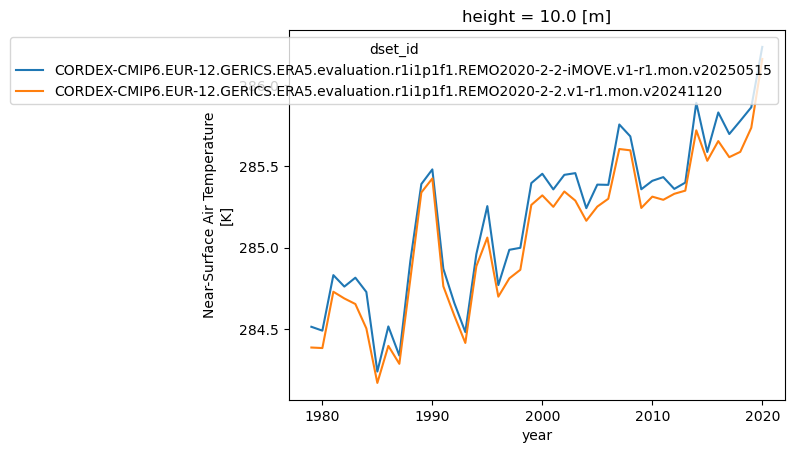

In [16]:
ds.tas.groupby("time.year").mean("time").mean(("rlon", "rlat")).plot(hue="dset_id")

## combine xarray datasets directly

In [ ]:
ensemble_ds = xr.concat(ds_list, dim=dset_dim, coords="minimal", compat="override", combine_attrs="drop_conflicts")
ensemble_ds